In [1]:
# Control whether Day 0 HAI data is used
USE_DEMOGRAPHIC_DATA_ONLY = False
# 4.4: Use only 3 specific vaccine strains
TASK_4_4_STRAINS_ONLY = False
vaccine_strains = [
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Austria/1359417/2021',
]
EPSILON = 1e-9

# Tasks




4.4 predict magnitude of antibody response - all 3 vaccine strains (D28)

**4.5 predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Geo mean
* Metric: Spearman correlation
* Full description: Geomean HAI across all variants

4.6 predict antibody breadth - all variants (D28)

4.10 predict antibody durability - all 3 vaccine strains (D365)

## Task 4.5: Focus
Breadth refers to how widely an antibody response covers different variants of a pathogen (not just the specific strain, but also related versions).
Want to measure a person's antibody response broadly, so we are predicting the 'average protective coverage' across the whole panel of flu variants.
Use the geometric mean (average used for antibody titers)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gmean, spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline

In [3]:
DATA_PATH = 'data/PART2-26-01-26_reorg/PART2-26-01-26_reorg'
train_participants = pd.read_csv(DATA_PATH + '/train_participants.tsv', sep='\t')

In [4]:
train_hai = pd.read_csv(DATA_PATH + '/train_hai.tsv', sep='\t')
if TASK_4_4_STRAINS_ONLY:
    train_hai = train_hai[train_hai['virus_strain'].isin(vaccine_strains)]

In [5]:
for name, df in {'train_hai': train_hai, 'train_participants': train_participants}.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(df.head(5))


TABLE: train_hai


,hai_id,participant_id,timepoint,virus_strain,value,material
0,ID_001__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_001,0.0,H1N1 A/South Carolina/1/1918,20.,Unknown
1,ID_001__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_001,28.0,H1N1 A/South Carolina/1/1918,40.,Unknown
2,ID_002__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_002,0.0,H1N1 A/South Carolina/1/1918,5.,Unknown
3,ID_002__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_002,28.0,H1N1 A/South Carolina/1/1918,5.,Unknown
4,ID_003__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_003,0.0,H1N1 A/South Carolina/1/1918,80.,Unknown



TABLE: train_participants


,participant_id,subject,biological_sex,race,min_age,max_age,geolocation,investigation_id,investigation_name,arm_id,arm_name,data_source,description,basic_curation,pubmed_ids,main_pmid,main_publication_author
0,SDY269.SUB112836,SUB112836,female,White,28,28,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
1,SDY269.SUB112849,SUB112849,female,Black or African American,39,39,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
2,SDY269.SUB112854,SUB112854,male,Black or African American,46,46,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
3,SDY269.SUB112860,SUB112860,female,White,32,32,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
4,SDY269.SUB112881,SUB112881,female,Black or African American,29,29,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)


### Data Cleaning
HAI
* Timepoint column only missing 1.89% of values, and value column missing 0.02% of values. We decide to drop these rows.
* We also make sure the value column is numeric.

Participants
* main_publication_author missing 47.55% of values, geolocation missing 20.18%, pubmed_ids missing 3.06%, main_pmid missing 3.06%
* We drop the publication column all together. Will address other missing values depending on task.

In [6]:
# --- Clean HAI ---
# Drop rows missing timepoint or value (small % of data)
train_hai = train_hai.dropna(subset=['timepoint', 'value'])
# Coerce value to numeric; rows that can't convert become NaN
train_hai['value'] = pd.to_numeric(train_hai['value'], errors='coerce')
# Drop any new NaNs introduced by coercion
train_hai = train_hai.dropna(subset=['value'])
# Remove placeholder strain entries
train_hai = train_hai[train_hai['virus_strain'] != '-']

# --- Clean Participants ---
train_participants = train_participants.drop(columns=['main_publication_author'])
# Normalize categorical fields
train_participants['biological_sex'] = train_participants['biological_sex'].str.lower().str.strip()
train_participants['race'] = train_participants['race'].replace({
    'race: unknown': 'Unknown',
    'race: other': 'Unknown',
})

In [7]:
hai_cols_to_keep = [
    'hai_id', 'participant_id', 'timepoint', 'virus_strain', 'value'
]
# Drop geolocation since it's missing ~20% of the data and not needed for this task
participant_cols_to_keep = [
    'participant_id', 'biological_sex', 'race', 'min_age',
]

train_merged = train_hai[hai_cols_to_keep].merge(
    train_participants[participant_cols_to_keep],
    on='participant_id',
    how='left'
)

train_merged = train_merged.dropna()
train_merged.head()

,hai_id,participant_id,timepoint,virus_strain,value,biological_sex,race,min_age
0,ID_001__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_001,0.0,H1N1 A/South Carolina/1/1918,20.0,female,Unknown,29
1,ID_001__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_001,28.0,H1N1 A/South Carolina/1/1918,40.0,female,Unknown,29
2,ID_002__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_002,0.0,H1N1 A/South Carolina/1/1918,5.0,female,Unknown,29
3,ID_002__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_002,28.0,H1N1 A/South Carolina/1/1918,5.0,female,Unknown,29
4,ID_003__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_003,0.0,H1N1 A/South Carolina/1/1918,80.0,female,Unknown,28


### Build the target variable (y) — Geomean of HAI at Day 28

In [8]:
d28 = train_merged[train_merged['timepoint'] == 28.0].copy()

# gmean requires all values > 0. HAI titers of 0 are common (undetectable). Replace 0 with a small
# positive value so gmean doesn't collapse to 0 for that participant.
d28['value'] = d28['value'].replace(0, EPSILON)

y = (
    d28.groupby('participant_id')['value']
    .apply(gmean)
    .reset_index()
    .rename(columns={'value': 'geomean_d28'})
)
# Log-transform HAI values (standard practice — brings them to a more linear scale)
y['geomean_d28'] = np.log1p(y['geomean_d28'])
y

,participant_id,geomean_d28
0,2016_UGA.ID_001,4.817830
1,2016_UGA.ID_002,3.771165
2,2016_UGA.ID_003,4.890995
3,2016_UGA.ID_004,3.526992
4,2016_UGA.ID_005,3.785576
...,...,...
3622,SDY887.SUB134259,6.240276
3623,SDY887.SUB134260,5.089261
3624,SDY887.SUB197783,3.273304
3625,SDY887.SUB197784,4.630776


### Build the features (X) — Day 0 HAI + demographics

In [9]:
# --- Day 0 baseline HAI ---
d0 = train_merged[train_merged['timepoint'] == 0.0].copy()
# Same zero-handling as target
d0['value'] = d0['value'].replace(0, EPSILON)
# Pivot: one row per participant, one column per virus strain
d0_wide = d0.pivot_table(
    index='participant_id',
    columns='virus_strain',
    values='value',
    aggfunc='mean'
).reset_index()
# Log-transform HAI values (standard practice — brings them to a more linear scale)
hai_cols = [c for c in d0_wide.columns if c != 'participant_id']
d0_wide[hai_cols] = np.log1p(d0_wide[hai_cols])
d0_wide.head()

virus_strain,participant_id,Anc B/Lee/1940,Anc B/Maryland/1959,Anc B/Singapore/1964,H1N1 A/Beijing/262/1995,H1N1 A/Brazil/11/1978,H1N1 A/Brisbane/2/2018,H1N1 A/Brisbane/59/2007,H1N1 A/California/7/2009,H1N1 A/Chile/1/1983,...,Vic B/Washington/2/2019,Yam B/Brisbane/3/2007,Yam B/Florida/4/2006,Yam B/Harbin/7/1994,Yam B/Massachusetts/2/2012,Yam B/Phuket/3073/2013,Yam B/Sichuan/379/1999,Yam B/Texas/6/2011,Yam B/Wisconsin/1/2010,Yam B/Yamagata/16/1988
0,2016_UGA.ID_001,NaN,NaN,NaN,3.713572,1.791759,NaN,2.397895,5.081404,1.791759,...,NaN,NaN,6.463029,6.463029,6.463029,5.771441,6.463029,5.081404,5.771441,5.081404
1,2016_UGA.ID_002,NaN,NaN,NaN,4.394449,1.791759,NaN,3.713572,3.044522,1.791759,...,NaN,NaN,4.394449,5.081404,4.394449,4.394449,5.081404,3.713572,4.394449,3.713572
2,2016_UGA.ID_003,NaN,NaN,NaN,4.394449,1.791759,NaN,2.397895,5.081404,2.397895,...,NaN,NaN,6.463029,7.155396,6.463029,6.463029,6.463029,5.771441,5.771441,5.771441
3,2016_UGA.ID_004,NaN,NaN,NaN,2.397895,1.791759,NaN,2.397895,2.397895,1.791759,...,NaN,NaN,4.394449,5.081404,4.394449,3.713572,5.771441,3.044522,3.713572,2.397895
4,2016_UGA.ID_005,NaN,NaN,NaN,2.397895,1.791759,NaN,1.791759,3.713572,1.791759,...,NaN,NaN,5.081404,5.081404,5.081404,4.394449,5.771441,4.394449,4.394449,3.713572


In [10]:
# Get demographics directly from the participants table
demo = train_participants[['participant_id', 'biological_sex', 'race', 'min_age']].copy()
demo = demo.dropna(subset=['biological_sex', 'race', 'min_age'])
# Encode categorical variables
demo = pd.get_dummies(demo, columns=['biological_sex', 'race'], drop_first=True)

# Merge Day 0 HAI + demographics into one feature table
X_df = d0_wide.merge(demo, on='participant_id', how='inner')

if USE_DEMOGRAPHIC_DATA_ONLY:
    X_df = demo  # demographic data only

In [11]:
X_df

,participant_id,Anc B/Lee/1940,Anc B/Maryland/1959,Anc B/Singapore/1964,H1N1 A/Beijing/262/1995,H1N1 A/Brazil/11/1978,H1N1 A/Brisbane/2/2018,H1N1 A/Brisbane/59/2007,H1N1 A/California/7/2009,H1N1 A/Chile/1/1983,...,Yam B/Wisconsin/1/2010,Yam B/Yamagata/16/1988,min_age,biological_sex_male,race_Asian,race_Black or African American,race_Multiracial,race_Native Hawaiian or Other Pacific Islander,race_Unknown,race_White
0,2016_UGA.ID_001,NaN,NaN,NaN,3.713572,1.791759,NaN,2.397895,5.081404,1.791759,...,5.771441,5.081404,29,False,False,False,False,False,True,False
1,2016_UGA.ID_002,NaN,NaN,NaN,4.394449,1.791759,NaN,3.713572,3.044522,1.791759,...,4.394449,3.713572,29,False,False,False,False,False,True,False
2,2016_UGA.ID_003,NaN,NaN,NaN,4.394449,1.791759,NaN,2.397895,5.081404,2.397895,...,5.771441,5.771441,28,False,False,False,False,False,True,False
3,2016_UGA.ID_004,NaN,NaN,NaN,2.397895,1.791759,NaN,2.397895,2.397895,1.791759,...,3.713572,2.397895,27,True,False,False,False,False,True,False
4,2016_UGA.ID_005,NaN,NaN,NaN,2.397895,1.791759,NaN,1.791759,3.713572,1.791759,...,4.394449,3.713572,25,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3742,SDY887.SUB134259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,85,True,False,False,False,False,False,True
3743,SDY887.SUB134260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,64,False,False,False,False,False,False,True
3744,SDY887.SUB197783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,64,False,False,False,False,False,True,False
3745,SDY887.SUB197784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,24,False,False,False,False,False,True,False


### Merge X and y, then train model

**Why Spearman correlation?**

This task uses Spearman correlation as its evaluation metric. Spearman only cares about
**rankings**. It converts all your true values and predictions into ranks (1st, 2nd, 3rd…)
and then checks whether those two rank orderings agree.

This is a good fit for antibody data because:
- HAI titers are noisy and vary across studies, so predicting exact values is unrealistic.
- What matters clinically is *relative* response: can we identify who will respond well vs. poorly?
- Spearman is also robust to outliers and non-linear relationships — if your predictions are
  monotonically related to the truth (always going in the right direction), Spearman rewards that
  even if the relationship isn't a straight line.

**Interpreting the score:**
A Spearman of 1.0 means perfect ranking agreement, 0.0 means no relationship, and -1.0 means
perfectly reversed rankings.

In [12]:
# Merge features and target
data = X_df.merge(y, on='participant_id', how='inner')

feature_cols = [c for c in data.columns if c not in ['participant_id', 'geomean_d28']]
X = data[feature_cols]
y_vals = data['geomean_d28']  # already log-transformed

print(f"Samples: {len(X)}")
print(f"Features: {len(feature_cols)}")

# Simple pipeline: impute remaining NaNs (from the pivot), then regress
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Cross-validated evaluation (the real score) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y_vals, cv=cv)
rho_cv, pval_cv = spearmanr(y_vals, y_pred_cv)
print(f"\nSpearman (5-fold CV): {rho_cv:.3f}  (p-value: {pval_cv:.4f})")

Samples: 3617
Features: 76

Spearman (5-fold CV): 0.661  (p-value: 0.0000)


### Why Cross-Validation?

The CV score above is our real evaluation. Each participant's prediction was made by a model
that **never saw that participant during training** (5-fold: train on 4/5 of the data, predict
the held-out 1/5, rotate). This tells us how the model would perform on new, unseen participants.

The train score is shown only as an overfitting diagnostic — a large gap between train and CV
means the model memorised noise rather than learning real patterns.

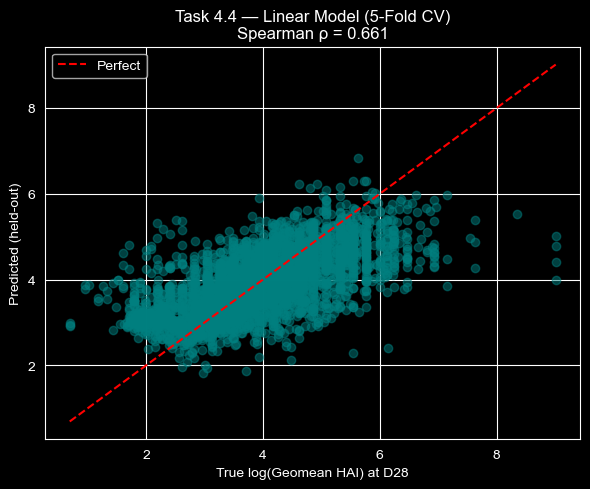

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals, y_pred_cv, alpha=0.5, color='teal')
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--', label='Perfect')
plt.xlabel('True log(Geomean HAI) at D28')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.4 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

### Next Steps

**1. Add Day 7 innate immune features (flow cytometry)**

The task description allows "Day 0 + Day 7 innate" features. The innate immune data lives in
`train_flow.tsv`, not in the HAI table.

Approach:
- Load `train_flow.tsv` and filter to `timepoint == 7`
- Pivot into one-row-per-participant format (similar to what we did with Day 0 HAI), using
  the `name` column as the new feature columns and `value` as the cell values
- Merge into `X_df` on `participant_id`
- Watch out for participant overlap — not everyone will have flow data, so decide whether
  to inner-join (fewer samples, no NaNs) or left-join (keep all samples, impute missing)

**2. Add Day 7 transcriptomics features**

`train_transcriptomics.tsv` contains gene expression data (RNA-Seq). This is high-dimensional
(thousands of genes per participant), so it needs special handling:
- Use the `.grp` files provided in the dataset to select only innate-related gene modules
  instead of using all genes
- Use `tpm_count` (transcripts per million) as the value
- Consider PCA or other dimensionality reduction before merging, since adding thousands of
  gene features directly will almost certainly cause overfitting with a linear model

**3. Try regularised models**

With many features (especially after adding flow + transcriptomics), plain LinearRegression
will overfit. Ridge or Lasso add a penalty that shrinks coefficients toward zero:
- **Ridge** — keeps all features but reduces their influence; good when many features
  contribute small effects (likely the case with immune data)
- **Lasso** — drives some coefficients to exactly zero, effectively doing feature selection;
  good if you suspect only a handful of features actually matter
- Both have an `alpha` hyperparameter that controls penalty strength — tune it with
  cross-validation using `RidgeCV` or `LassoCV`

**4. Experiment with non-linear models**

Random Forest or XGBoost can capture interactions between features (e.g. "high baseline HAI
+ young age predicts strong response") that linear models miss. These are worth trying once
the feature set is more complete.

In [14]:
results = pd.DataFrame({
    'participant_id': data['participant_id'].values,
    'predicted_geomean_d28': np.expm1(y_pred_cv),  # reverse the log1p transform
})
results

,participant_id,predicted_geomean_d28
0,2016_UGA.ID_001,183.925400
1,2016_UGA.ID_002,110.017117
2,2016_UGA.ID_003,66.573763
3,2016_UGA.ID_004,47.322504
4,2016_UGA.ID_005,63.900643
...,...,...
3612,SDY887.SUB134259,45.247517
3613,SDY887.SUB134260,47.851932
3614,SDY887.SUB197783,21.487410
3615,SDY887.SUB197784,31.913247
